<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif;">

<h1 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Aquaverse Short Course Part II: Generating MDN Predictions
</h1>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    This notebook illustrates how to use the pretrained <b>Mixture Density Network (MDN)</b> models within the Aquaverse framework to generate predictions of selected Water Quality (WQ) parameters on your own data. The notebook will explain how to generate predictions/results from both <i>in situ/spectral</i> data as well as from <i>satellite/cube</i> data. This notebook will also present a comparison of the MDN's performance versus standard operational algorithms for some variables.
</p>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    The satellite-derived products for Sentinel-2 MultiSpectral Instrument (MSI) and Landsat-8/9 Operational Land Imager (OLI) are directly available for download via the <a href="https://ladsweb.modaps.eosdis.nasa.gov/stream/" target="_blank" style="color:#0056b3;text-decoration:underline;font-weight:bold;">Satellite-based Tool for Rapid Evaluation of Aquatic environMents (STREAM)</a> website. The Aquaverse toolbox also supports other satellite-product combinations, which are also mentioned in this notebook.
</p>

<h3 style="color: #004080; margin-top: 25px;"><b>Course Objectives</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #d35400;">■</span> <b>01. Supported Combinations:</b> List all the available sensor-product combinations that are supported by the current Aquaverse toolbox.</li>
    <li><span style="color: #d35400;">■</span> <b>02. Spectral Estimation:</b> Leverage the <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">GLORIA dataset</a> to show how the Aquaverse toolbox can be used to extract WQ estimates from <i>in situ/spectral</i> <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> data.</li>
    <li><span style="color: #d35400;">■</span> <b>03. Architecture:</b> Understand MDN structures and output parameterization.</li>
    <li><span style="color: #d35400;">■</span> <b>04. Satellite data download:</b> Download some example satellite <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> cubes to use for testing with the Aquaverse toolbox.</li>
    <li><span style="color: #d35400;">■</span> <b>05. Satellite product estimates:</b> Visualize MDN outputs from satellite <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> cubes, both the pixel estimates as well as the associated uncertainties.</li>
</ul>

<div style="background-color: #fcf8e3; color: #8a6d3b; padding: 15px; border: 1px solid #faebcc; border-left: 6px solid #8a6d3b; margin: 20px 0; font-weight: 500;">
    <strong>Requirement:</strong> Assumes that the user has already run the first notebook in this tutorial (<a href="AQV_1_MDN_explained.ipynb" style="color: #0056b3; text-decoration: underline; font-weight: bold;">AQV_1_MDN_explained.ipynb</a>) and has already correctly installed the toolbox and downloaded the <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">GLORIA dataset</a>.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="margin-bottom: 20px;">
    <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
    <span style="color: #444;">Science Systems and Applications, Inc. / NASA Goddard Space Flight Center</span><br>
    <span style="color: #666;">August 2026</span>
</div>

<h4 style="color: #004080; margin-bottom: 10px;">Technical Contacts</h4>
<table style="width: 100%; border-collapse: collapse; border: 1px solid #ddd;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Domain</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Section Lead</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Email</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">BPs & IOP Products</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Ryan E. O'Shea</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:ryan.oshea@ssaihq.com" style="color: #0056b3; font-weight: bold;">ryan.oshea@ssaihq.com</a></td>
        </tr>
        <tr style="background-color: #fafafa;">
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Uncertainties</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Arun Saranathan</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:arun.saranathan@ssaihq.com" style="color: #0056b3; font-weight: bold;">arun.saranathan@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Atmospheric Correction</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Akash Ashapure</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:akash.ashapure@ssaihq.com" style="color: #0056b3; font-weight: bold;">akash.ashapure@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Stream Website</td>
            <td style="padding: 10px; border: 1px solid #ddd;">William Wainwright</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:william.wainwright@ssaihq.com" style="color: #0056b3; font-weight: bold;">william.wainwright@ssaihq.com</a></td>
        </tr>
    </tbody>
</table>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 1: Available satellite product pairs for WQ estimation
</h2>

<p style="font-size: 1.15em; color: #222222;">
    Import the Aquaverse <code>MDN</code> WQ package included with this course. Then we will print/visualize the available satellite-product combination supported by this package at the currnet stage. The product pairs visualized in this section correspond to the combinations made public by the Aquaverse team. If you would like to inquire about a specific combination not shown here contact the Aquaverse team for support with the combination you need.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    The following cell performs the import of all functions needed by this notebook, not just the ones needed by this section.
</div>


<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 2.1
</div>

</div>

In [1]:
# Import the base python packages needed for this notebook
import numpy                                                          as np
import scipy
import os
import subprocess
from   pathlib                    import Path
from   urllib.request             import urlretrieve
import zipfile
import matplotlib                                                     as mpl
import matplotlib.pyplot                                              as plt
import matplotlib.patches                                             as patches
from   matplotlib                 import ticker
from   matplotlib.colors          import LogNorm
import sys
sys.path.append("C:\\Users\\asaranat\\OneDrive - NASA\\Code\\MDN-STREAM\\")

# Supressing tensorflow based warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('tensorflow_probability').setLevel(logging.ERROR)

# Import some specific functions and packages from MDN implementation
from   MDN                        import get_sensor_bands, get_tile_data
from   MDN                        import current_support 
from   MDN                        import get_gloria_trainTestData, get_args
from   MDN                        import get_spectral_preds
from   MDN                        import create_scatterplots_trueVsPred, performance
from   MDN                        import OC, resample_Rrs 

[compat_patch] NumPy version: 2.3.3
[compat_patch] Applied NumPy _randomstate_ctor patch.
[compat_patch] TensorFlow version: 2.20.0
[compat_patch] Applied TensorFlow TrackableReference patch (tracking.base).
[compat_patch] NumPy version: 2.3.3
[compat_patch] TensorFlow version: 2.20.0
Modified RC Params: dict_keys(['backend'])


In [2]:
'Print all the product/sensor model combinations available in the current MDN tool box'

### need to modify this function to only print sensor and product combinations that are available in the current MDN tool box
current_support()

Model-1: predicts chl,tss,cdom from OLI data
Model-2: predicts chl from OLI data
Model-3: predicts chl,tss,cdom from OLCI data
Model-4: predicts chl from OLCI data
Model-5: predicts chl,tss,cdom from MSI data
Model-6: predicts chl from MSI data
Model-7: predicts chl,tss,cdom,pc from S3A data
Model-8: predicts chl,tss,cdom,pc from S3B data
Model-9: predicts aph,chl,tss,pc,ad,ag,cdom from HICO data
Model-10: predicts aph,chl,tss,pc,ad,ag,cdom from PRISMA data
Model-11: predicts aph,chl,tss,pc,ad,ag,cdom from PACE data
Model-12: predicts aph,chl,tss,pc,ad,ag,cdom from PACE-sat data
Model-13: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667 from VI data
Model-14: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667 from MOD data
Model-15: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667 from MERIS data


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h4 style="color: #004080; margin-top: 0; margin-bottom: 15px; font-weight: 700;">Supported Sensor-Product Matrix</h4>

<div style="width: 100%; overflow-x: auto; margin-bottom: 20px; box-sizing: border-box;">
    <table style="width: 100%; min-width: 800px; border-collapse: collapse; border: 1px solid #ddd; font-size: 0.95em;">
        <thead style="background-color: #f2f2f2;">
            <tr>
                <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080; font-weight: 600;">Product</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">OLI</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">OLCI</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">MSI</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">S3A / S3B</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">HICO</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">PRISMA</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">PACE (sat)</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">VIIRS</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">MODIS</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">MERIS</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">Chl <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Chlorophyll-a)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
            </tr>
            <tr style="background-color: #fafafa;">
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">TSS <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Total Suspended Solids)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">CDOM / aCDOM <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Absorption)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(440 nm)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(440 nm)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(440 nm)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(440 nm)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
            </tr>
            <tr style="background-color: #fafafa;">
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">PC <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Phycocyanin)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">aph <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Phytoplankton Abs.)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.8em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.85em;">(443/488/555/667)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.8em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.85em;">(443/488/555/667)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.8em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.85em;">(443/488/555/667)</span></td>
            </tr>
            <tr style="background-color: #fafafa;">
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">ad / ag <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Detritus / Gelbstoff)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">aNAP <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Non-Algal Particle Abs.)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
            </tr>
        </tbody>
    </table>
</div>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Methodology Note:</strong> 
    Unless explicitly noted above, the parameters 
    <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">a<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">d</sub></span>, 
    <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">a<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">NAP</sub></span>, 
    <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">a<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">CDOM</sub></span>, and 
    <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">a<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">ph</sub></span> 
    are hyperspectral at the resolution of the sensor.
</div>

<div style="background-color: #fdf2f2; color: #9b1c1c; padding: 15px; border: 1px solid #f8b4b4; border-left: 6px solid #e11d48; margin: 20px 0; box-sizing: border-box; border-radius: 4px;">
    <strong style="font-size: 1.1em;">Internal Note: Things to change in this section</strong>
    <ol style="margin-top: 5px; margin-bottom: 0; padding-left: 20px;">
        <li>Combine S3A and S3B into OLCI.</li>
        <li>Why do we use the instrument name for all others and the platform name for PACE?</li>
        <li>Change the <code>current_support</code> function to only print the sensor-product combinations.</li>
        <li> Need to add to Zsd to this also.
    </ol>
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    The following cell is used setup the matplotlib environment for displaying the results in this notebook.
</p>


</div>

In [3]:
# Set display parameters via MATPLOTLIB for this notebook
plt.rcParams.update({"text.usetex": False,})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['mathtext.default'] = 'regular'
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
mrkSize = 15
ASPECT = "auto"
cmap = "jet"

mpl.rcParams['xtick.labelsize'] = SMALL_SIZE
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 2: Generating predictions using spectral data
</h2>

<p style="font-size: 1.15em; color: #222222;">
    One way to use the <code>MDN</code> WQ package is to generate predictions from spectral data. Such data may come from <i>in situ</i> <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> measurements at selected locations or a set of user-selected satellite pixel <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>. In either case, the dataset we want to use for predictions is structured as a 2D array. This section will walk you through how to generate predictions for these datasets and how to visualize them.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    For this demo, we will use the <i>in situ</i> <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> from the <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">GLORIA dataset</a> as our spectral data. Because these <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> data also feature collocated measurements of WQ parameters, this dataset can be used to evaluate model performance. For this demo, we will also resample the data to the spectral resolution of the Sentinel-3 OLCI.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 2.2
</div>

</div>

In [4]:
# Set the GLORIA folder and extract the data
gloria_folder = Path().cwd() / 'data/GLORIA_2022/'
assert gloria_folder.is_dir(), f"No folder found art {gloria_folder}"

# Set the sensor we want to work with
sensor = "OLCI"
products = "chl,tss"

# Get the GLORIA data at the resolution of the OLCI sensor
x_data, y_data, gid_data = get_gloria_trainTestData(sensor=sensor, out_var=products.split(','),
                                                    save_flag=False, load_exists=False,rand_seed=42,
                                                    rem_flagged=True, gloria_folder=gloria_folder,
                                                    flag_name='GLORIA_qc_flags.csv', rrs_name='GLORIA_Rrs.csv',
                                                    bg_name='GLORIA_meta_and_lab.csv', gloria_only=True,
                                                    train_mode=False)


Bands with responses outside of range [350, 899]: 
 [np.float64(900.0), np.float64(940.0), np.float64(1020.0)]

Creating data for bands
 [np.float64(400.0), np.float64(412.5), np.float64(442.5), np.float64(490.0), np.float64(510.0), np.float64(560.0), np.float64(620.0), np.float64(665.0), np.float64(673.75), np.float64(681.25), np.float64(708.75), np.float64(753.75), np.float64(761.25), np.float64(764.375), np.float64(767.5), np.float64(778.75), np.float64(865.0), np.float64(885.0)]


100%|██████████| 7572/7572 [00:06<00:00, 1260.07it/s]


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0; font-weight: 600; border-bottom: 2px solid #2c3e50; padding-bottom: 8px;">
    Function: get_spectral_preds
</p>

<p style="font-size: 1.05em; color: #222222; margin-top: 10px;">
    This function generates Mixture Density Network (MDN) predictions and optional uncertainty estimates for a given 2D spectral dataset using the default pre-trained model.
</p>

<hr style="border: 0; border-top: 1px solid #e0e0e0; margin: 20px 0;">

<h3 style="color: #2c3e50; font-size: 1.2em; margin-bottom: 12px;">⚙️ Parameters</h3>

<table style="width: 100%; border-collapse: collapse; margin-bottom: 20px; font-size: 0.95em;">
    <thead>
        <tr style="border-bottom: 2px solid #2c3e50; text-align: left;">
            <th style="padding: 8px; font-weight: 600;">Parameter</th>
            <th style="padding: 8px; font-weight: 600;">Type</th>
            <th style="padding: 8px; font-weight: 600;">Default</th>
            <th style="padding: 8px; font-weight: 600;">Description</th>
        </tr>
    </thead>
    <tbody>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 8px; font-weight: 600; font-family: 'Courier New';">test_x</td>
            <td style="padding: 8px; color: #666;">np.ndarray</td>
            <td style="padding: 8px; color: #c0392b; font-style: italic;">Required</td>
            <td style="padding: 8px;">Input spectral data matrix of shape <code>nSamples X nBands</code>.</td>
        </tr>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 8px; font-weight: 600; font-family: 'Courier New';">sensor</td>
            <td style="padding: 8px; color: #666;">str</td>
            <td style="padding: 8px; color: #c0392b; font-style: italic;">Required</td>
            <td style="padding: 8px;">Target sensor name (e.g., <code>"OLCI"</code>).</td>
        </tr>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 8px; font-weight: 600; font-family: 'Courier New';">products</td>
            <td style="padding: 8px; color: #666;">str</td>
            <td style="padding: 8px; color: #c0392b; font-style: italic;">Required</td>
            <td style="padding: 8px;">Comma-separated products to predict and extract (e.g., <code>"chl,aph"</code>).</td>
        </tr>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 8px; font-weight: 600; font-family: 'Courier New';">op_mode</td>
            <td style="padding: 8px; color: #666;">str</td>
            <td style="padding: 8px; color: #c0392b; font-style: italic;">Required</td>
            <td style="padding: 8px;">
                Operation mode controlling network processing dimensions:<br>
                • <code>"select"</code>: Returns only the max-likelihood predictions closest to the ensemble median.<br>
                • <code>"full"</code>: Returns full predictions for all models in the ensemble.
            </td>
        </tr>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 8px; font-weight: 600; font-family: 'Courier New';">return_uncert</td>
            <td style="padding: 8px; color: #666;">bool</td>
            <td style="padding: 8px; font-family: 'Courier New';">True</td>
            <td style="padding: 8px;">Determines whether the function calculates and returns uncertainty metrics.</td>
        </tr>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 8px; font-weight: 600; font-family: 'Courier New';">uncert_mode</td>
            <td style="padding: 8px; color: #666;">str</td>
            <td style="padding: 8px; color: #c0392b; font-style: italic;">Required</td>
            <td style="padding: 8px;">
                Uncertainty format configuration:<br>
                • <code>"limits"</code>: Returns upper and lower distribution limits.<br>
                • <code>"composite"</code>: Returns the total distance between the upper and lower limit.
            </td>
        </tr>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 8px; font-weight: 600; font-family: 'Courier New';">scaler_mode</td>
            <td style="padding: 8px; color: #666;">str</td>
            <td style="padding: 8px; font-family: 'Courier New';">"invert"</td>
            <td style="padding: 8px;">Options: <code>{"invert", "non_invert"}</code>. Controls whether to apply inverse scaling to outputs.</td>
        </tr>
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 8px; font-weight: 600; font-family: 'Courier New';">progress_vis</td>
            <td style="padding: 8px; color: #666;">bool</td>
            <td style="padding: 8px; font-family: 'Courier New';">True</td>
            <td style="padding: 8px;">Toggles the visual visibility of the <code>tqdm</code> progress bars.</td>
        </tr>
    </tbody>
</table>

<hr style="border: 0; border-top: 1px solid #e0e0e0; margin: 20px 0;">

<h3 style="color: #2c3e50; font-size: 1.2em; margin-bottom: 12px;">📤 Returns</h3>
<p style="margin-bottom: 8px;">The function outputs a tuple containing the following structures:</p>
<ul style="padding-left: 20px; margin-top: 0;">
    <li style="margin-bottom: 8px;"><strong><code>estimates</code></strong> (<code>dict</code> or <code>np.ndarray</code>): Primary predictions containing only columns belonging to the requested products. Shapes are <code>nModels X nSamples X nProducts</code> (For <code>op_mode="select"</code> we will have nModels==1</code>).</li>
    <li style="margin-bottom: 8px;"><strong><code>[uncert]</code></strong> (<code>dict</code> or <code>np.ndarray</code>, <em>Optional</em>): Product-specific uncertainty metrics. <strong>Only returned if <code>return_uncert=True</code></strong>. Structure of this dictionary will depend on setting of <code>uncert_mode</code></li>
    <li style="margin-bottom: 8px;"><strong><code>selected_slices</code></strong> (<code>dict</code>): Map of updated output slices per predicted product.</li>
</ul>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong>Technical Note:</strong> Take care when unpacking results, as the returned variables change depending on whether <code>return_uncert</code> is set to true or false.
</div>

</div>

In [ ]:
# Get the predictions for the GLORIA data using the MDN model for OLCI sensor
wq_estimates, wq_uncert, wq_selected_slices =get_spectral_preds(test_x=x_data, op_mode="select", sensor=sensor, products= products, 
                                                                return_uncert= "True", uncert_mode= "limits", scaler_mode = "invert", progress_vis= True)

Processing MDN ensemble for uncertainty: 100%|██████████| 10/10 [00:02<00:00,  3.88it/s]


In [6]:
'Compare the true and predicted values and get a set of regression metrics'
inp_str = []
for key in wq_selected_slices:
    str1 = (performance(f'', y_data[:, wq_selected_slices[key]], np.squeeze(wq_estimates['pred'][0, :, wq_selected_slices[key]])).replace('|', ''))
    inp_str += [str1.replace('   ', '\n')]
    print(f"{key}:{str1}")

# Also get the uncertainty as a percentage of the predicted value
uncert_perc = ((wq_uncert['high_lim'] - wq_uncert['low_lim']) / wq_estimates['pred']) * 100

chl:            MdSA: 27.520   SSPB: -1.636   Slope:  0.899   MSA: 50.636   RMSLE:  0.651   MAE: 20.089   <=0NaN:  0.000
tss:            MdSA: 34.339   SSPB:  1.217   Slope:  0.667   MSA: 76.594   RMSLE:  0.914   MAE: 15.381   <=0NaN:  0.000


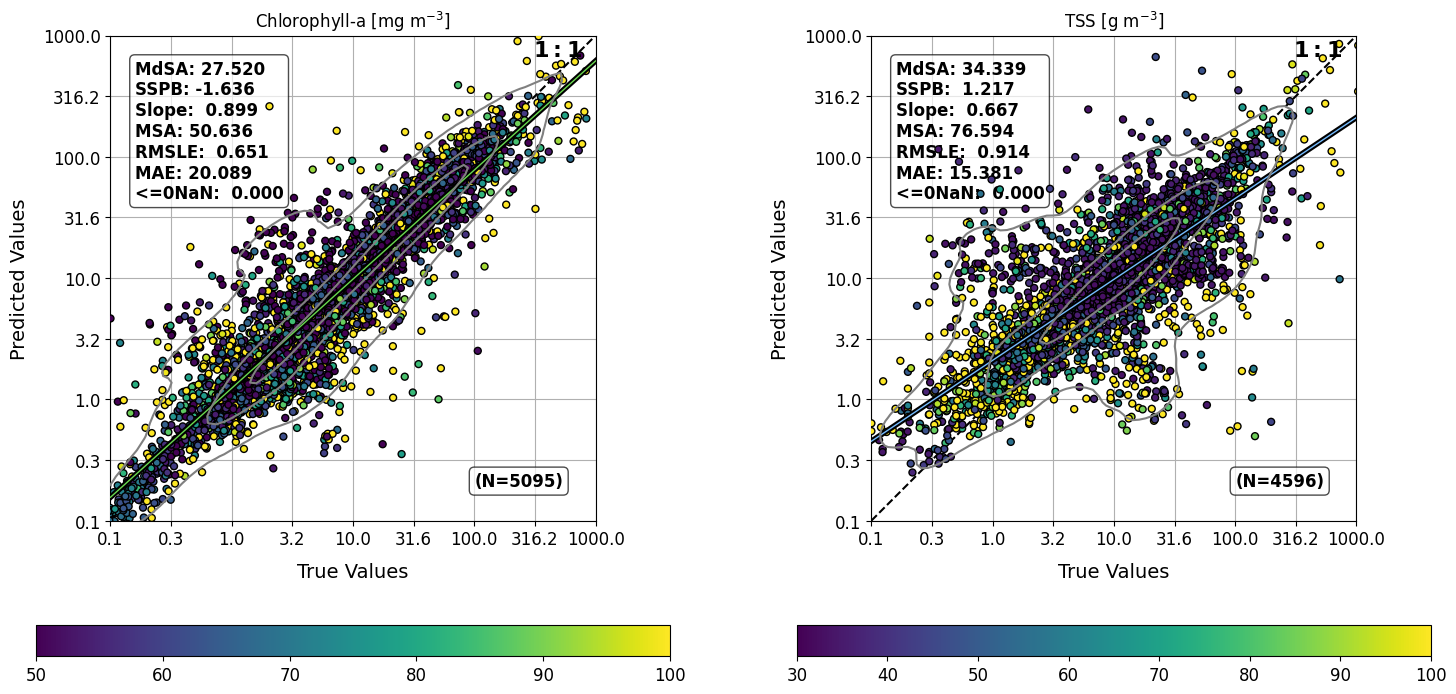

In [9]:
'Show a graphical comparision of the true and predicted values'
create_scatterplots_trueVsPred(y_data, np.squeeze(wq_estimates['pred']), color=np.squeeze(uncert_perc), short_name=[r'Chlorophyll-a [$mg~m^{-3}$]', r'TSS [$g~m^{-3}$]'], 
                        x_label=['True Values', 'True Values'], y_label=['Predicted Values', 'Predicted Values'], inplot_str=inp_str,
                        title="", maxv_b=[3, 3], minv_b=[-1, -1], ipython_mode=True, vmin_b=[50., 30.], vmax_b=[100., 100.])

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<p style="font-size: 1.15em; color: #222222;margin-top: 0;">
    The scatterplot above shows a graphical comparison between the true and predicted values. Additionally, the plot displays the values of various regression metrics which can be used to provide a wholesale analysis of the regression performance. For a more detailed description of the various metrics, see Section 3.2 of <a href="https://www.frontiersin.org/journals/remote-sensing/articles/10.3389/frsen.2024.1383147/full" target="_blank" style="color: #2980b9; text-decoration: none; font-weight: 600;">Saranathan et al. 2024</a>. While these plots show exceptional performance it is worth noting that the performance on novel test samples are not guaranteed to be as good, but comprehensive experiments on unseen test sets have shown that the MDNs outperfom operational algorithms on unseen test sets-- see experiments in the various MDN papers for exact details.
</p>

<p style="font-size: 1.15em; color: #222222;margin-bottom: 0;">
    Further, each test point is colored by the total uncertainty scaled as percentage of the predicted value. Note that generally the uncertainty is high at the extremes of the point cloud (i.e. far away from the 1:1 line), which indicates that generally points with high error have high uncertainty. That said there are also examples of lower error with high uncertainty indicating that this metric is a measure of the models confidence in its prediction and not a direct proxy for the error.
</p>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<p style="font-size: 1.15em; color: #222222; margin: 0;">
    Let us now compare the performance of the MDN predictions against the operational algorithm (OC-v) for Chlorophyll-a to get a clear sense of the advantages of MDNs vis-à-vis conventional algorithms.
</p>

</div>

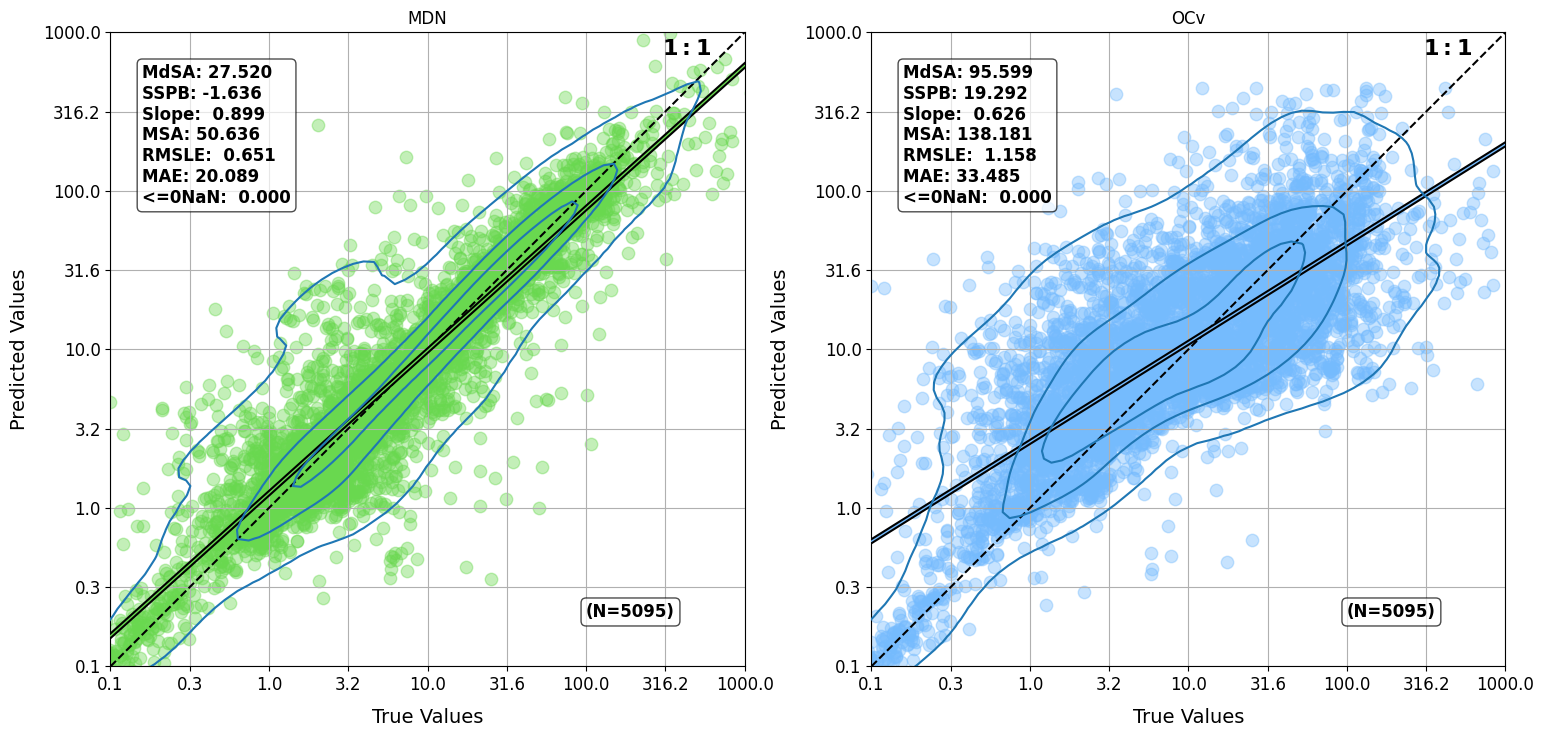

In [24]:
'Get predictions from the OC model'
wvl_bands = get_sensor_bands(sensor=sensor)
oc_preds = OC(x_data, wvl_bands, sensor=sensor, algorithm='OC', num=3)

'Let us get create a label data that is only true chlorophyll-a values'
y_chla_true = np.asarray([np.squeeze(y_data[:, wq_selected_slices['chl']]), np.squeeze(y_data[:, wq_selected_slices['chl']])]).T

'Stack the predictions from the two algorithms '
y_chla_pred = np.asarray([np.squeeze(wq_estimates['pred'][0, :, wq_selected_slices['chl']]), np.squeeze(oc_preds)]).T


'Compare the true and predicted values and get a set of regression metrics'
alg_str = []
for ctr in range(2):
    str1 = (performance(f'', y_chla_true[:, ctr], y_chla_pred[:, ctr]).replace('|', ''))
    alg_str += [str1.replace('   ', '\n')]
    #print(f"{key}:{str1}")


'Show a graphical comparision of the true and predicted values'
create_scatterplots_trueVsPred(y_chla_true, y_chla_pred, short_name=[r'MDN', r'OCv'], 
                        x_label=['True Values', 'True Values'], y_label=['Predicted Values', 'Predicted Values'], inplot_str=alg_str,
                        title="", maxv_b=[3, 3], minv_b=[-1, -1], ipython_mode=True)


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<p style="font-size: 1.15em; color: #222222; margin: 0;">
    Across a large variety of regression metrics the MDN outperforms most semi-analytical algorithms across the full suite of the regression metrics under consideration. While we illustrate this for the specific WQ parameter: Chlorophyll-a, similar results are seen across a wide range of WQ parameters.
</p>

</div>